# Label Propagation — Classifier Ablation

Reproduces APORIA-LP ablation experiment under different classifier choices (Appendix E) -- twelve alternative classifier/projection combinations contrasted with the Wasserstein-on-Fisher baseline (Table 13).

---

## Setup

In [1]:
import os
import pathlib

# allow execution from either the repo root or code/
ROOT = pathlib.Path.cwd()
if ROOT.name == "code":
    os.chdir(ROOT.parent)
    
os.environ["OPENBLAS_NUM_THREADS"] = "4"


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.linear_model    import LogisticRegression
from sklearn.svm             import LinearSVC
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline

import aporia as ap


In [3]:
# ---------------------------------------------------------------
# Load dataset + model metadata from a TOML config.
# ---------------------------------------------------------------
CONFIG_PATH = "config/socrates.toml"

cfg = ap.load_config(CONFIG_PATH)

# expose aliases used downstream
model_names           = cfg.model_names
figures_dir           = cfg.cache.fig_dir
model_latextags       = cfg.model_latextags
best_reg_lambda       = cfg.experiment.best_lambda
maxResponsesPerPrompt = cfg.dataset.max_responses_per_prompt

FISHER_KWARGS = dict(
    lambda_reg          = best_reg_lambda,
    normalise           = True,
    normalise_by_trace  = True,
)


## Configuration

Same dataset / model config as `ProjectorsAnalysis`. The variable being swept here is not the projector dimensionality but the **propagation strategy** — i.e., which classifier is placed after the (fixed) projection.

In [4]:
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = ap.matplotlib_latex_preamble(cfg)


## Data

In [5]:
df = ap.load_dataframe(cfg)


In [6]:
import time
from tqdm.auto import tqdm

minutes = 0   # set > 0 to delay execution (e.g. overnight scheduling)
for _ in tqdm(range(minutes), desc="Sleeping before execution"):
    time.sleep(60)


Sleeping before execution: 0it [00:00, ?it/s]

In [7]:
prompt_ids_by_model = ap.prompt_ids_by_model(df, cfg)
model_ids           = list(prompt_ids_by_model.keys())


## Method definitions

Each entry in `CONFIGS` is a self-contained experiment spec:

| Group | Projection | Propagator / Classifier | Reviewer tag |
|---|---|---|---|
| `ours` | Fisher 1-D | Wasserstein LP | our method |
| `ours` | Identity 384-D | Wasserstein LP | ablation: no projection |
| `centroid` | Fisher 1-D | Nearest centroid (Euclidean) | geometric baseline |
| `centroid` | Identity 384-D | Nearest centroid (Euclidean) | geometric baseline |
| `centroid` | Identity 384-D | Nearest centroid (Cosine) | geometric baseline |
| `centroid-feat` | Centroid features (3-D) | Logistic Regression | cos-to-centroid + length |
| `lr` | Fisher 1-D | Logistic Regression | classical linear |
| `lr` | Identity 384-D | Logistic Regression | 384-D LR |
| `svm` | Fisher 1-D | Linear SVM | classical linear |
| `svm` | Identity 384-D | Linear SVM | 384-D SVM |
| `knn` | Fisher 1-D | k-NN (k=5) | non-parametric |
| `knn` | Identity 384-D | k-NN (k=5) | non-parametric |

> **Protocol**: identical to `ProjectorsAnalysis` — same `StratifiedShuffleSplit` seeds, `n_splits=10`, `test_fraction=1/3`, no subsampling (`train_fractions=None`), `n_iter=100` for the Wasserstein method, `n_iter=1` for deterministic sklearn classifiers.

In [8]:
# ---------------------------------------------------------------------------
# sklearn estimators are wrapped in a StandardScaler pipeline for the
# full 384-D Identity space, where feature scales differ; Fisher-projected
# data is already 1-D so scaling is less critical but harmless.
# ---------------------------------------------------------------------------

def lr_pipeline():
    return Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=1000))])

def svm_pipeline():
    return Pipeline([("scaler", StandardScaler()), ("clf", LinearSVC(C=1.0, max_iter=2000))])

def knn_pipeline(k=5):
    return Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier(n_neighbors=k))])


CONFIGS = [
    # ------------------------------------------------------------------ our method
    dict(
        label             = "Wasserstein (Fisher 1D)",
        tag               = "BA_wass_fisher1d",
        group             = "ours",
        projector_class   = ap.FisherProjection,
        projector_kwargs  = FISHER_KWARGS,
        propagator_class  = ap.WassersteinLabelPropagator,
        propagator_kwargs = {},
        n_iter            = 100,   # stochastic scorer — many iters
    ),
    dict(
        label             = "Wasserstein (Identity 384D)",
        tag               = "BA_wass_identity384d",
        group             = "ours",
        projector_class   = ap.IdentityProjection,
        projector_kwargs  = {},
        propagator_class  = ap.WassersteinLabelPropagator,
        propagator_kwargs = {},
        n_iter            = 100,
    ),

    # --------------------------------------------------------- centroid baselines
    dict(
        label             = "Centroid Eucl. (Fisher 1D)",
        tag               = "BA_centroid_eucl_fisher1d",
        group             = "centroid",
        projector_class   = ap.FisherProjection,
        projector_kwargs  = FISHER_KWARGS,
        propagator_class  = ap.CentroidPropagator,
        propagator_kwargs = {"metric": "euclidean"},
        n_iter            = 1,
    ),
    dict(
        label             = "Centroid Eucl. (Identity 384D)",
        tag               = "BA_centroid_eucl_identity384d",
        group             = "centroid",
        projector_class   = ap.IdentityProjection,
        projector_kwargs  = {},
        propagator_class  = ap.CentroidPropagator,
        propagator_kwargs = {"metric": "euclidean"},
        n_iter            = 1,
    ),
    dict(
        label             = "Centroid Cosine (Identity 384D)",
        tag               = "BA_centroid_cosine_identity384d",
        group             = "centroid",
        projector_class   = ap.IdentityProjection,
        projector_kwargs  = {},
        propagator_class  = ap.CentroidPropagator,
        propagator_kwargs = {"metric": "cosine"},
        n_iter            = 1,
    ),

    # ---------------------------------------- centroid-feature LR (reviewer ask)
    dict(
        label             = "LR (Centroid-feat 3D)",
        tag               = "BA_lr_centroidfeat3d",
        group             = "centroid-feat",
        projector_class   = ap.CentroidFeaturesProjection,
        projector_kwargs  = {"lambda_reg": best_reg_lambda},
        propagator_class  = ap.SKLearnPropagator,
        propagator_kwargs = {"estimator": lr_pipeline()},
        n_iter            = 1,
    ),

    # -------------------------------------------------- logistic regression
    dict(
        label             = "LR (Fisher 1D)",
        tag               = "BA_lr_fisher1d",
        group             = "lr",
        projector_class   = ap.FisherProjection,
        projector_kwargs  = FISHER_KWARGS,
        propagator_class  = ap.SKLearnPropagator,
        propagator_kwargs = {"estimator": lr_pipeline()},
        n_iter            = 1,
    ),
    dict(
        label             = "LR (Identity 384D)",
        tag               = "BA_lr_identity384d",
        group             = "lr",
        projector_class   = ap.IdentityProjection,
        projector_kwargs  = {},
        propagator_class  = ap.SKLearnPropagator,
        propagator_kwargs = {"estimator": lr_pipeline()},
        n_iter            = 1,
    ),

    # ----------------------------------------------------------------- SVM
    dict(
        label             = "SVM (Fisher 1D)",
        tag               = "BA_svm_fisher1d",
        group             = "svm",
        projector_class   = ap.FisherProjection,
        projector_kwargs  = FISHER_KWARGS,
        propagator_class  = ap.SKLearnPropagator,
        propagator_kwargs = {"estimator": svm_pipeline()},
        n_iter            = 1,
    ),
    dict(
        label             = "SVM (Identity 384D)",
        tag               = "BA_svm_identity384d",
        group             = "svm",
        projector_class   = ap.IdentityProjection,
        projector_kwargs  = {},
        propagator_class  = ap.SKLearnPropagator,
        propagator_kwargs = {"estimator": svm_pipeline()},
        n_iter            = 1,
    ),

    # ----------------------------------------------------------------- kNN
    dict(
        label             = "kNN-5 (Fisher 1D)",
        tag               = "BA_knn5_fisher1d",
        group             = "knn",
        projector_class   = ap.FisherProjection,
        projector_kwargs  = FISHER_KWARGS,
        propagator_class  = ap.SKLearnPropagator,
        propagator_kwargs = {"estimator": knn_pipeline(k=5)},
        n_iter            = 1,
    ),
    dict(
        label             = "kNN-5 (Identity 384D)",
        tag               = "BA_knn5_identity384d",
        group             = "knn",
        projector_class   = ap.IdentityProjection,
        projector_kwargs  = {},
        propagator_class  = ap.SKLearnPropagator,
        propagator_kwargs = {"estimator": knn_pipeline(k=5)},
        n_iter            = 1,
    ),
]


## Run all configurations

## Experiment

In [9]:
# Each config is cached in its own sub-directory so partial re-runs are safe.
# Re-running a cell with overwrite_cache=False is a no-op if the cache exists.

raw_results = {}                                # label -> DataFrame

for entry in CONFIGS:
    lbl = entry["label"]
    tag = entry["tag"]
    print(f"\n>>> Running: {lbl}")

    raw_results[lbl] = ap.run_full_label_propagation_study(
        df, cfg,
        projector_class   = entry["projector_class"],
        projector_kwargs  = entry["projector_kwargs"],
        propagator_class  = entry["propagator_class"],
        propagator_kwargs = entry["propagator_kwargs"],
        train_fractions   = None,                 # full training set
        n_iter            = entry["n_iter"],
        test_fraction     = 1 / 3,
        n_splits          = 10,
        ref_lambda_reg    = best_reg_lambda,      # for agreement_fisher
        use_cache         = True,
        cache_dir         = f"{cfg.cache.root}/{tag}",
        overwrite_cache   = False,
        logskip           = True,
    )



>>> Running: Wasserstein (Fisher 1D)


Model:   0%|          | 0/10 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

...

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

## Aggregate results

In [10]:
# Tag each frame with its label and group, then concatenate.

dfs = []
label_to_group = {cfg["label"]: cfg["group"] for cfg in CONFIGS}

for lbl, res_df in raw_results.items():
    if res_df is None or len(res_df) == 0:
        print(f"[warn] empty result for {lbl}, skipping.")
        continue
    tagged = res_df.copy()
    tagged["method"] = lbl
    tagged["group"]  = label_to_group[lbl]
    dfs.append(tagged)

df_all = pd.concat(dfs, ignore_index=True)

In [11]:
# Aggregate: one row per method, averaged over all (model, prompt, split) runs.

summary = (
    df_all
    .groupby(["method", "group"])
    .agg(
        acc_mean          = ("accuracy",              "mean"),
        acc_std           = ("accuracy",              "std"),

        f1_mean           = ("f1",                   "mean"),
        f1_std            = ("f1",                   "std"),

        prec_mean         = ("precision",            "mean"),
        prec_std          = ("precision",            "std"),

        rec_mean          = ("recall",               "mean"),
        rec_std           = ("recall",               "std"),

        margin_mean       = ("mean_margin",          "mean"),
        margin_std        = ("std_margin",           "mean"),

        abs_margin_mean   = ("mean_abs_margin",      "mean"),
        abs_margin_std    = ("std_abs_margin",       "mean"),

        agreement_mean    = ("agreement_fisher",     "mean"),
        agreement_std     = ("agreement_fisher",     "std"),

        agreement_conf_mean = ("agreement_fisher_confident", "mean"),
        agreement_conf_std  = ("agreement_fisher_confident", "std"),
    )
    .reset_index()
)

# Preserve the insertion order of CONFIGS.
label_order = [cfg["label"] for cfg in CONFIGS]
summary["method"] = pd.Categorical(summary["method"], categories=label_order, ordered=True)
summary = summary.sort_values("method").reset_index(drop=True)

## Grouped bar chart — Accuracy and F1 by method

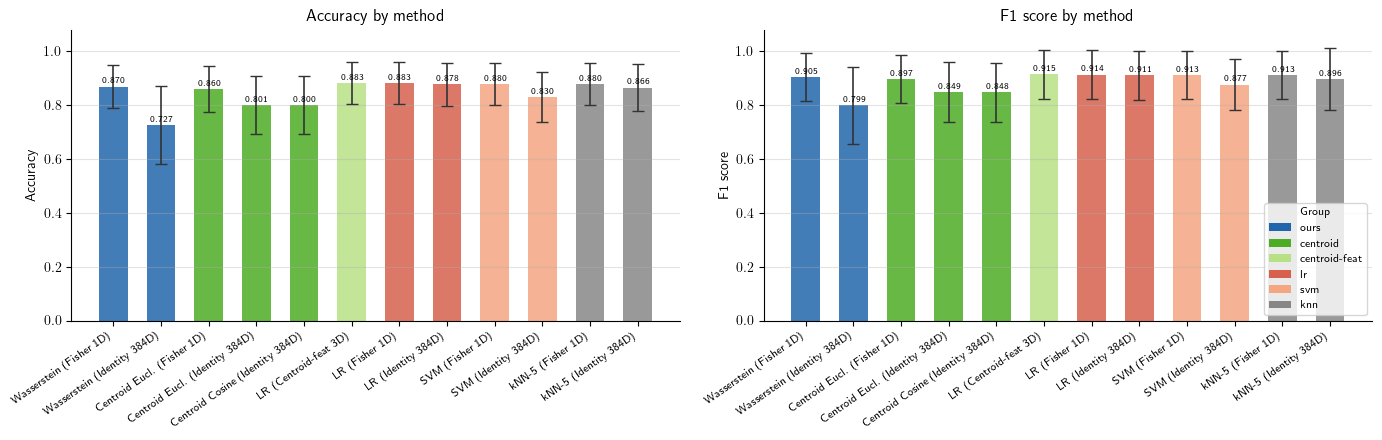

In [12]:
# Colour palette: one colour per group.
GROUP_COLORS = {
    "ours":         "#2166ac",
    "centroid":     "#4dac26",
    "centroid-feat": "#b8e186",
    "lr":           "#d6604d",
    "svm":          "#f4a582",
    "knn":          "#878787",
}

colors  = [GROUP_COLORS[cfg["group"]] for cfg in CONFIGS if cfg["label"] in summary["method"].values]
labels  = summary["method"].astype(str).tolist()
x       = np.arange(len(labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=False)

for ax, (metric_mean, metric_std, ylabel, title) in zip(
    axes,
    [
        ("acc_mean", "acc_std", "Accuracy",  "Accuracy by method"),
        ("f1_mean",  "f1_std",  "F1 score",  "F1 score by method"),
    ],
):
    bars = ax.bar(
        x,
        summary[metric_mean],
        yerr   = summary[metric_std],
        color  = colors,
        width  = 0.6,
        capsize = 4,
        ecolor  = "#333333",
        alpha   = 0.85,
        error_kw = dict(lw=1.2),
    )

    # value labels on top of bars
    for bar, val in zip(bars, summary[metric_mean]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=6.5,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(0, 1.08)
    ax.grid(axis="y", alpha=0.35)
    ax.spines[["top", "right"]].set_visible(False)

# legend for groups
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=c, label=g)
    for g, c in GROUP_COLORS.items()
]
axes[1].legend(
    handles=legend_elements, title="Group",
    loc="lower right", fontsize=8, title_fontsize=8,
)

plt.tight_layout()
fig.savefig(f"{figures_dir}/BaselinesAnalysis_bars.pdf", bbox_inches="tight")
plt.show()

## Fisher agreement — how much do baselines agree with our Wasserstein–Fisher method?

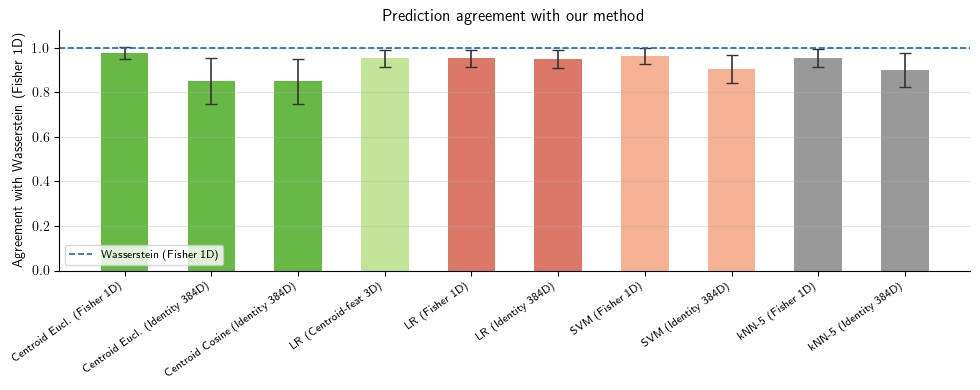

In [13]:
# Only baselines (exclude our own method from the agreement plot).
baselines = summary[summary["group"] != "ours"].reset_index(drop=True)

x2      = np.arange(len(baselines))
colors2 = [GROUP_COLORS[g] for g in baselines["group"]]
labels2 = baselines["method"].astype(str).tolist()

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(
    x2,
    baselines["agreement_mean"],
    yerr   = baselines["agreement_std"],
    color  = colors2,
    width  = 0.55,
    capsize = 4,
    ecolor  = "#333333",
    alpha   = 0.85,
    error_kw = dict(lw=1.2),
)

ax.axhline(1.0, color="#2166ac", ls="--", lw=1.2, label="Wasserstein (Fisher 1D)")
ax.set_xticks(x2)
ax.set_xticklabels(labels2, rotation=35, ha="right", fontsize=8)
ax.set_ylabel(r"Agreement with Wasserstein (Fisher 1D)")
ax.set_title("Prediction agreement with our method")
ax.set_ylim(0, 1.08)
ax.grid(axis="y", alpha=0.35)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(f"{figures_dir}/BaselinesAnalysis_agreement.pdf", bbox_inches="tight")
plt.show()

## Summary table (display)

In [14]:
display_cols = [
    "method", "group",
    "acc_mean",  "acc_std",
    "f1_mean",   "f1_std",
    "prec_mean", "rec_mean",
    "agreement_mean", "agreement_std",
]
summary[display_cols].style.format({
    c: "{:.3f}" for c in display_cols if c not in ("method", "group")
})

,method,group,acc_mean,acc_std,f1_mean,f1_std,prec_mean,rec_mean,agreement_mean,agreement_std
0,Wasserstein (Fisher 1D),ours,0.870,0.081,0.905,0.088,0.922,0.892,1.000,0.000
1,Wasserstein (Identity 384D),ours,0.727,0.145,0.799,0.143,0.856,0.775,0.724,0.151
2,Centroid Eucl. (Fisher 1D),centroid,0.860,0.084,0.897,0.090,0.929,0.872,0.977,0.028
3,Centroid Eucl. (Identity 384D),centroid,0.801,0.108,0.849,0.111,0.937,0.787,0.850,0.102
4,Centroid Cosine (Identity 384D),centroid,0.800,0.107,0.848,0.110,0.938,0.785,0.849,0.101
5,LR (Centroid-feat 3D),centroid-feat,0.883,0.077,0.915,0.091,0.907,0.926,0.952,0.039
6,LR (Fisher 1D),lr,0.883,0.077,0.914,0.092,0.907,0.926,0.952,0.039
7,LR (Identity 384D),lr,0.878,0.080,0.911,0.091,0.908,0.916,0.949,0.041
8,SVM (Fisher 1D),svm,0.880,0.078,0.913,0.089,0.909,0.920,0.962,0.035
9,SVM (Identity 384D),svm,0.830,0.093,0.877,0.093,0.910,0.849,0.905,0.063


In [15]:
df_md = summary.copy()

# Extract text inside parentheses → Space
df_md["Space"] = df_md["method"].str.extract(r"\((.*?)\)")

# Remove parentheses part from method → Method
df_md["Method"] = df_md["method"].str.replace(r"\s*\(.*?\)", "", regex=True)

df_md["Accuracy"] = (
    df_md["acc_mean"].mul(100).map("{:.1f}".format)
    + " (" +
    df_md["acc_std"].mul(100).map("{:.1f}".format)
    + ")"
)

df_md["F1"] = (
    df_md["f1_mean"].mul(100).map("{:.1f}".format)
    + " (" +
    df_md["f1_std"].mul(100).map("{:.1f}".format)
    + ")"
)

df_md = df_md.sort_values(by="Space", ascending=False)

df_md = df_md[["Method", "Space", "Accuracy", "F1"]]

markdown_table = df_md.to_markdown(index=False)
print(markdown_table)

| Method          | Space            | Accuracy    | F1          |
|:----------------|:-----------------|:------------|:------------|
| Wasserstein     | Identity 384D    | 72.7 (14.5) | 79.9 (14.3) |
| Centroid Eucl.  | Identity 384D    | 80.1 (10.8) | 84.9 (11.1) |
| Centroid Cosine | Identity 384D    | 80.0 (10.7) | 84.8 (11.0) |
| LR              | Identity 384D    | 87.8 (8.0)  | 91.1 (9.1)  |
| SVM             | Identity 384D    | 83.0 (9.3)  | 87.7 (9.3)  |
| kNN-5           | Identity 384D    | 86.6 (8.7)  | 89.6 (11.6) |
| Wasserstein     | Fisher 1D        | 87.0 (8.1)  | 90.5 (8.8)  |
| Centroid Eucl.  | Fisher 1D        | 86.0 (8.4)  | 89.7 (9.0)  |
| LR              | Fisher 1D        | 88.3 (7.7)  | 91.4 (9.2)  |
| SVM             | Fisher 1D        | 88.0 (7.8)  | 91.3 (8.9)  |
| kNN-5           | Fisher 1D        | 88.0 (7.8)  | 91.3 (9.0)  |
| LR              | Centroid-feat 3D | 88.3 (7.7)  | 91.5 (9.1)  |


## Summary statistics export -- Table 13

In [16]:
# Group header labels for the LaTeX table.
GROUP_LABELS = {
    "ours":         r"\textbf{Ours}",
    "centroid":     "Centroid",
    "centroid-feat": "Centroid features",
    "lr":           "Logistic Regression",
    "svm":          "SVM",
    "knn":          "$k$-NN",
}

rows = []
last_group = None

for _, r in summary.iterrows():
    # insert a \midrule when the group changes
    if r["group"] != last_group:
        if last_group is not None:
            rows.append({"Method": r"\midrule", "Acc": "", "F1": "", "Prec": "", "Rec": "", r"$\%$Agree": ""})
        last_group = r["group"]

    rows.append({
        "Method":       str(r["method"]),
        "Acc":          ap.fmt_pct(r["acc_mean"],  r["acc_std"]),
        "F1":           ap.fmt_pct(r["f1_mean"],   r["f1_std"]),
        "Prec":         ap.fmt_pct(r["prec_mean"], r["prec_std"]),
        "Rec":          ap.fmt_pct(r["rec_mean"],  r["rec_std"]),
        r"$\%$Agree":   ap.fmt_pct(r["agreement_mean"], r["agreement_std"]),
    })

table_df = pd.DataFrame(rows)

latex_table = table_df.to_latex(
    index         = False,
    escape        = False,
    column_format = "lcccccc",
    caption       = "Comparison of propagation strategies. Accuracy and F1 are macro-averaged over all (model, prompt, split) runs; \\%Agree is agreement with the Wasserstein--Fisher method.",
    label         = "tab:baselines",
)

print(latex_table)

\begin{table}
\caption{Comparison of propagation strategies. Accuracy and F1 are macro-averaged over all (model, prompt, split) runs; \%Agree is agreement with the Wasserstein--Fisher method.}
\label{tab:baselines}
\begin{tabular}{lcccccc}
\toprule
Method & Acc & F1 & Prec & Rec & $\%$Agree \\
\midrule
Wasserstein (Fisher 1D) & 87.0 (8.1) & 90.5 (8.8) & 92.2 (8.4) & 89.2 (10.3) & 100.0 (0.0) \\
Wasserstein (Identity 384D) & 72.7 (14.5) & 79.9 (14.3) & 85.6 (12.7) & 77.5 (18.6) & 72.4 (15.1) \\
\midrule &  &  &  &  &  \\
Centroid Eucl. (Fisher 1D) & 86.0 (8.4) & 89.7 (9.0) & 92.9 (8.2) & 87.2 (10.9) & 97.7 (2.8) \\
Centroid Eucl. (Identity 384D) & 80.1 (10.8) & 84.9 (11.1) & 93.7 (9.2) & 78.7 (13.9) & 85.0 (10.2) \\
Centroid Cosine (Identity 384D) & 80.0 (10.7) & 84.8 (11.0) & 93.8 (9.2) & 78.5 (13.8) & 84.9 (10.1) \\
\midrule &  &  &  &  &  \\
LR (Centroid-feat 3D) & 88.3 (7.7) & 91.5 (9.1) & 90.7 (8.3) & 92.6 (10.7) & 95.2 (3.9) \\
\midrule &  &  &  &  &  \\
LR (Fisher 1D) & 88.3 (7.7

## Breackdown of results by model

In [17]:
# Optional: also break down by model to see per-model variance.

summary_by_model = (
    df_all
    .groupby(["method", "group", "model_id"])
    .agg(
        acc_mean = ("accuracy", "mean"),
        f1_mean  = ("f1",       "mean"),
    )
    .reset_index()
)

summary_by_model["model_name"] = summary_by_model["model_id"].map(model_names)

# pivot for a quick overview
pivot = summary_by_model.pivot_table(
    index   = "method",
    columns = "model_name",
    values  = "f1_mean",
)
pivot = pivot.reindex(index=label_order)
pivot

model_name,DeepSeek-7B,Gemma-27B,Gemma-9B,Llama-8B,Mistral-7B,Phi-14B,Qwen-15B,Qwen-32B,Solar-11B,Yi-9B
method,,,,,,,,,,
Wasserstein (Fisher 1D),0.941975,0.928972,0.914040,0.925421,0.920696,0.838632,0.887107,0.890676,0.867606,0.952686
Wasserstein (Identity 384D),0.851122,0.815399,0.791488,0.829983,0.827020,0.709756,0.794602,0.794681,0.718200,0.905213
Centroid Eucl. (Fisher 1D),0.937181,0.920855,0.904473,0.920309,0.909660,0.831289,0.878449,0.881945,0.861610,0.946281
Centroid Eucl. (Identity 384D),0.912629,0.853261,0.851190,0.898741,0.852384,0.758251,0.830150,0.824136,0.821572,0.915281
Centroid Cosine (Identity 384D),0.912123,0.851943,0.852631,0.897945,0.852145,0.757876,0.829270,0.822893,0.821853,0.913078
LR (Centroid-feat 3D),0.946918,0.940664,0.926970,0.932473,0.935103,0.840661,0.897984,0.902087,0.879578,0.962626
LR (Fisher 1D),0.947096,0.940829,0.926761,0.932363,0.934685,0.839301,0.897460,0.901150,0.879279,0.962523
LR (Identity 384D),0.944881,0.937755,0.922257,0.928803,0.930356,0.841207,0.892316,0.897458,0.871282,0.961368
SVM (Fisher 1D),0.945748,0.937408,0.924388,0.931676,0.931584,0.842158,0.895810,0.899519,0.877739,0.961177


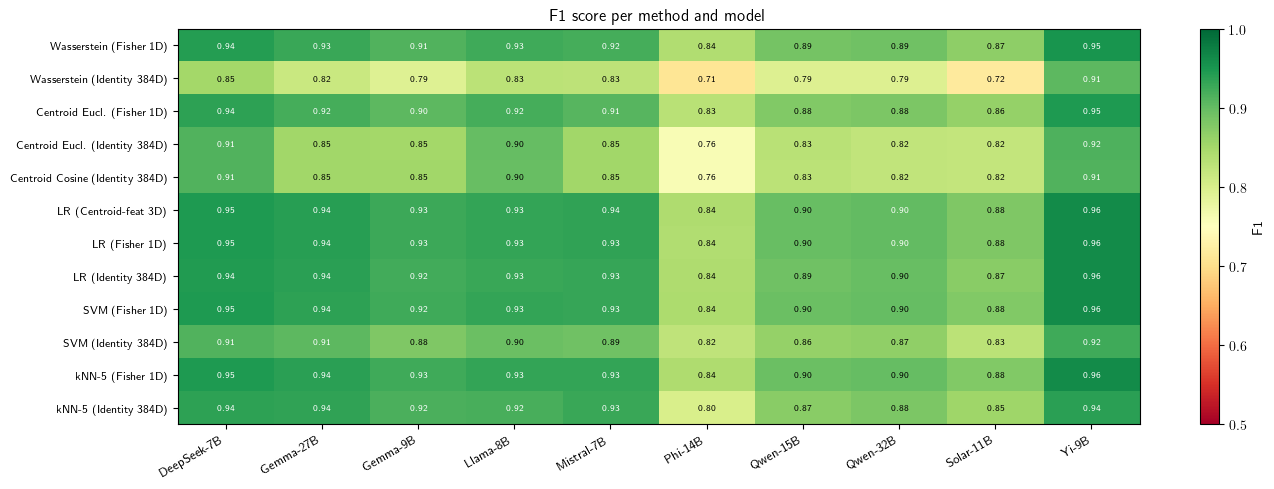

In [18]:
fig, ax = plt.subplots(figsize=(14, 5))

data = pivot.values
im   = ax.imshow(data, aspect="auto", cmap="RdYlGn", vmin=0.5, vmax=1.0)

ax.set_xticks(np.arange(pivot.shape[1]))
ax.set_xticklabels(pivot.columns, rotation=30, ha="right", fontsize=9)

ax.set_yticks(np.arange(pivot.shape[0]))
ax.set_yticklabels(pivot.index.astype(str), fontsize=8)

for (i, j), val in np.ndenumerate(data):
    if not np.isnan(val):
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=6.5,
                color="black" if 0.4 < val < 0.9 else "white")

plt.colorbar(im, ax=ax, label="F1")
ax.set_title("F1 score per method and model")
plt.tight_layout()
fig.savefig(f"{figures_dir}/BaselinesAnalysis_heatmap.pdf", bbox_inches="tight")
plt.show()